### Simon's problem
Input: a function $f:Σ^n→Σ^m$ \
Promise: there exists a string $s∈Σ^n$ such that $[f(x)=f(y)]⇔[(x=y)∨(x⊕s=y)]$ for all $x,y∈Σ^n$ \
Output: the string $s$

Case 1: $s=0^n$ \
$[f(x)=f(y)]⇔[x=y]$ i.e, equivalent to f being a one-to-one function

Case 2: $s≠0^n$ \
$f$ is two-to-one and the two input strings must take the form $w$ and $w⊕s$ for some string $w$.


It's important to recognize that there can only be one string $s$ that works if the promise is met, so there's always a unique correct answer for functions that satisfy the promise. \
The only thing that matters about the actual output strings is whether they're the same or different for different choices of input strings.

### Simon's Circuit

<img src="./images/Simon.svg" width=500>
no phase kickback

We're interested in the probability for the measurements to result in each possible string $y∈Σ^n$ \
$$
p(y) = \left\|\frac{1}{2^n} \sum_{x\in\Sigma^n} (-1)^{x\cdot y} \vert f(x) \rangle \right\|^2.
$$

$range(f)={f(x):x∈Σ^n}$


for each string $z∈range(f)$, the set of all input strings that cause the function to evaluate to this output string $z$ is $f^{−1}({z})$ \
$f^{−1}({z})={x∈Σ^n:f(x)=z}$
The set $f^{−1}({z})$ is known as the preimage of ${z}$ under $f$

$$
p(y) =
\left\|
\frac{1}{2^n}
\sum_{z\in\operatorname{range}(f)}
\Biggl(\sum_{x\in f^{-1}(\{z\})}  (-1)^{x\cdot y}\Biggr)
\vert z \rangle
\right\|^2.
$$

$$
\left\vert \sum_{x\in f^{-1}(\{z\})}  (-1)^{x\cdot y} \right\vert^2
$$ 
for an arbitrary selection of $z∈range(f)$


If $s=0^n$ then $f$ is a one-to-one function and there's always just a single element $x∈f^{−1}({z})$. The value of the expression 1 in this case.


If $s≠0^n$ then there are exactly two strings in the set $f^{−1}({z})$ To be precise, if we choose $w∈f^{−1}({z})$ to be any one of these two strings, then the other string must be $w⊕s$ by the promise in Simon's problem. \
​We evaluate 
${|(−1)^{w⋅y}+(−1)^{(w⊕s)⋅y}|}^2 = {|(−1)^{w⋅y}(1+(−1)^{s⋅y})|}^2 = {|1+(−1)^{y⋅s}|}^2 = 
                                                                            \begin{cases}
                                                                            4 &\text{if\ } y⋅s=0 \\
                                                                            0 &\text{if\ } y⋅s=1
                                                                            \end{cases}$


So, it turns out that the value obtained is independent of the specific choice of $z∈range(f)$ in both cases.

Case 1: $s=0^n$ \
In this case the function $f$ is one-to-one, so there are $2^n$ strings $z∈range(f)$, and we obtain\
$$
p(y) = \frac{1}{2^{2n}} \cdot 2^n = \frac{1}{2^n}.
$$

Case 2: $s≠0^n$ \
In this case $f$ is two-to-one, so there are $2^{n−1}$ elements in $range(f)$
$$
p(y)
= \frac{1}{2^{2n}} \sum_{z\in\operatorname{range}(f)}
\Biggl\vert \sum_{x\in f^{-1}(\{z\})} (-1)^{x\cdot y} \Biggr\vert^2
=
\begin{cases}
\frac{1}{2^{n-1}} & y \cdot s = 0\\[1mm]
0 & y \cdot s = 1
\end{cases}
$$

#### Classical post-processing

By running the circuit $k$ times, we obtain strings $y^1,...,y^{k} \in \Sigma^n.$

We form a matrix $M$ having $k$ rows and $n$ columns by taking the bits of these strings as binary-valued entries.

$$
M = \begin{pmatrix}
 y^1_{n-1} & \cdots & y^1_{0}\\[1mm]
 y^2_{n-1} & \cdots & y^2_{0}\\[1mm]
 \vdots & \ddots & \vdots \\[1mm]
 y^{k}_{n-1} & \cdots & y^{k}_{0}
 \end{pmatrix}
$$

imagine for a moment that we do know the string $s,$ and we form a column vector $v$ from the bits of the string $s = s_{n-1} \cdots s_0$ as follows.

$$
v = \begin{pmatrix}
s_{n-1}\\
\vdots\\
s_0
\end{pmatrix}
$$

If we perform the matrix-vector multiplication $M v$ modulo $2$ — meaning that we perform the multiplication as usual and then take the remainder of the entries of the result after dividing by $2$ — we obtain the all-zero vector.

$$
M v = \begin{pmatrix}
y^1 \cdot s\\
y^2 \cdot s\\
\vdots\\[1mm]
y^{k} \cdot s
\end{pmatrix}
= \begin{pmatrix}
0\\
0\\
\vdots\\[1mm]
0
\end{pmatrix}
$$

with $k = n + r$ for an arbitrary choice of a positive integer $r,$ the probability that the vectors corresponding to $0^n$ and $s$ are alone in the null space of $M$ is at least $1 - 2^{-r}$.

In [239]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

In [240]:
def simon_query(s):
    # Create a quantum circuit implementing a query gate for the
    # Simon's problem.
    n = len(s)
    m = n  # number of output qubits, can be changed if needed

    qc = QuantumCircuit(n + m)  # n input qubits and m output qubits
    
    for i in range(n):
        qc.cx(i, n + i)  # copy input to output (initialization step)

    # Now, apply CNOT gates based on the secret string s
    for i, bit in  enumerate(reversed(s)):  # reversed because we want to start from the least significant (leftmost/topmost) bit
        if bit == "1":
            qc.cx(i, n + i) # CNOT from input qubit i to output qubit i+n
            
    return qc

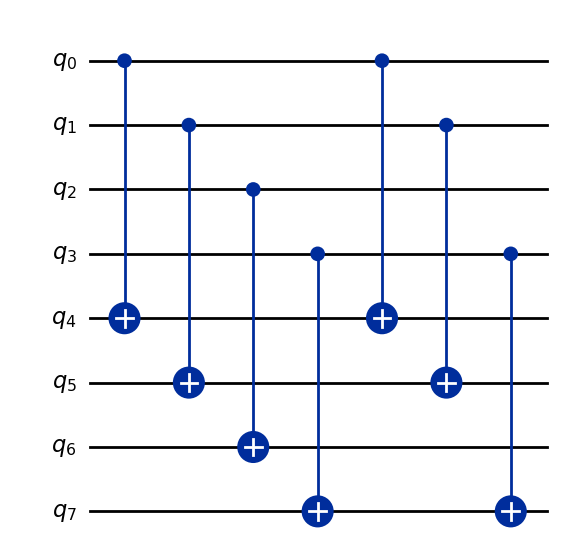

In [241]:
display(simon_query("1011").draw(output="mpl"))

In [242]:

def simon_circuit(function: QuantumCircuit):
    n = function.num_qubits // 2    # divide and round down to get a number
    m = n  # number of output qubits, can be changed if needed

    qc = QuantumCircuit(n + m, n)  # n input qubits, m output qubits, and n classical bits for measurement

    # Step 1: Initialize the output qubits to |0> and input qubits to |+>
    qc.h(range(n))  # Apply Hadamard to input qubits
    qc.barrier()

    # Step 2: Apply the Simon's query function
    qc.compose(function, inplace=True)  # modify the current circuit
    qc.barrier()

    # Step 3: Apply Hadamard to the input qubits again
    qc.h(range(n))

    # Step 4: Measure the input qubits
    qc.measure(range(n), range(n))

    return qc

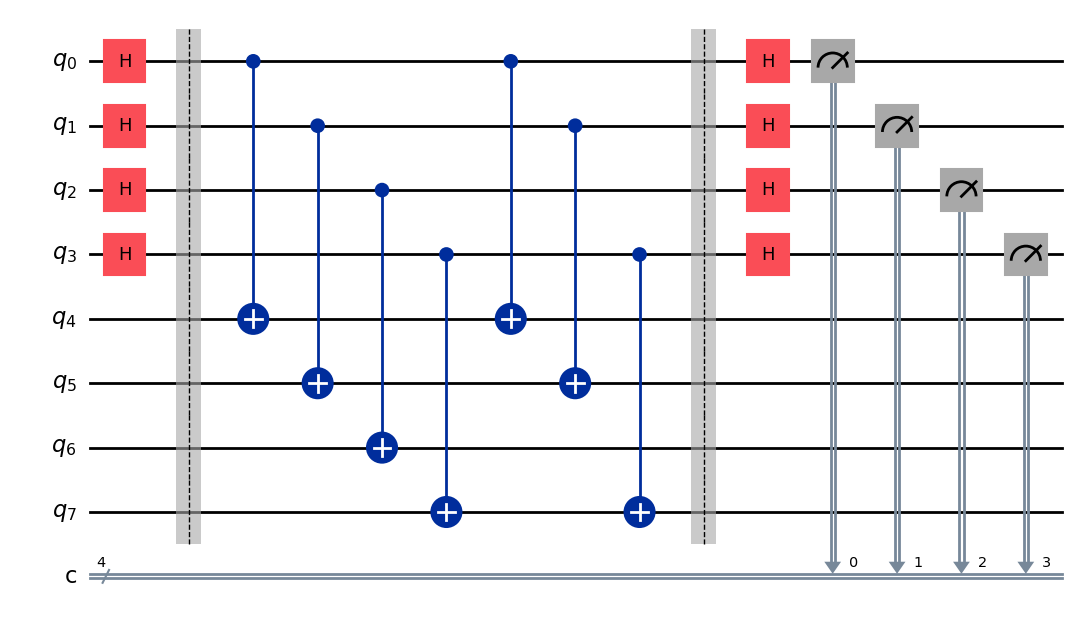

In [243]:
simon_circuit(simon_query("1011")).draw(output="mpl")

In [283]:
import numpy as np

def solve_simultaneous_eq(A, b):
    # Solve the system of linear equations Ax = b over GF(2) using Gaussian elimination.
    A = A.copy() % 2
    b = b.copy() % 2
    m, n = A.shape
    x = np.zeros(n, dtype=int)

    # Forward elimination to get row echelon form (upper triangular)
    row = 0
    for col in range(n):
        pivot = -1
        for r in range(row, m):
            if A[r, col] == 1: 
                pivot = r
                break
        if pivot == -1:
            continue  # free variable
        # Swap rows
        A[[row, pivot]] = A[[pivot, row]] # swap row at index 'row' with row at index 'pivot'
        b[[row, pivot]] = b[[pivot, row]] 

        # Eliminate below
        for r in range(row + 1, m):
            if A[r, col] != 0:
                factor = A[r, col] / A[row, col]
                A[r] -= factor * A[row]
                b[r] -= factor * b[row]

        row += 1
            
    # Identify pivot columns
    pivot_cols = []
    for row in range(m):
        pivot = np.where(np.abs(A[row]) > 0)[0]     # find indices of non-zero elements in the row
        if pivot.size > 0:
            pivot_cols.append(pivot[0])     # first non-zero element is the pivot
            
    # Free variables: columns without pivot
    free_vars = [c for c in range(n) if c not in pivot_cols]
            
    # Back-substitution: bottom-up
    for row in reversed(range(m)):
        if not np.any(np.abs(A[row]) > 0):
            continue
        col = pivot_cols[row]
        sum_right = np.dot(A[row, col+1:], x[col+1:])
        x[col] = (b[row].item() - sum_right) / A[row, col].item()

    # Generate non-trivial solutions using free variables
    for indx in free_vars:
        x[indx] = 1

    return x

In [284]:
B = np.array([[1, 0, 1, 1],
              [0, 1, 1, 0],
              [1, 1, 0, 0],
              [0, 0, 0, 0]], dtype=float)
b = np.array([[0], [0], [0], [0]], dtype=float)
solution = solve_simultaneous_eq(B, b)
print("One non-trivial solution (possible secret string):", solution)

One non-trivial solution (possible secret string): [0 0 0 1]


In [285]:
def simon_algorithm(function: QuantumCircuit):
    # Determine if a function is constant or balanced.

    qc = simon_circuit(function)
    n = function.num_qubits // 2   # divide and round down to get a number
    nshots = n+100  # number of shots to run the simulation

    result = AerSimulator().run(qc, shots=nshots, memory=True).result()
    measurements = result.get_memory()
    counts = result.get_counts()
    
    A = np.zeros((0, n), dtype=float)  # Initialize an empty matrix to store the equations with n columns
    for bitstring in counts.keys():
        A = np.vstack([A, np.array([int(b) for b in bitstring])])   # Add the new bitstring as a row to the matrix A
    
    b = np.zeros((A.shape[0], 1), dtype=float)  # Right-hand side of the equations (all zeros)
    
    solution = solve_simultaneous_eq(A, b)
    bitstring = ''.join(map(str, solution))
    print("One non-trivial solution (possible secret string):", bitstring)

    return counts

In [286]:
secret_string = "010100"
counts = simon_algorithm(simon_query(secret_string))

One non-trivial solution (possible secret string): 010100


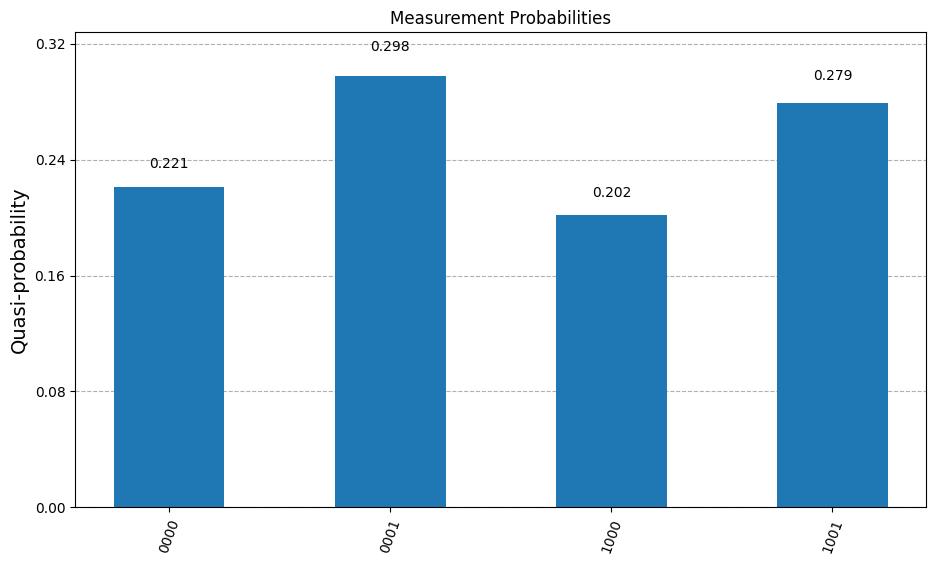

In [253]:
from qiskit.visualization import plot_histogram

# convert counts -> probabilities
total = sum(counts.values())
probs = {state: cnt / total for state, cnt in counts.items()}

fig = plot_histogram(probs, title="Measurement Probabilities")

fig.set_size_inches(10, 6) # Set figure size (width, height) in inches

# Get the Axes object
ax = fig.axes[0]

# Adjust bar width (default ~0.8, smaller width = more gap)
for p in ax.patches:
    p.set_width(0.5)  # reduce width → more gap between bars

display(fig)

In [254]:
for bitstring in counts.keys():   # iterate over measured states
    accum = 0
    for i in range(len(secret_string)):
        accum += int(secret_string[i]) * int(bitstring[i])
    accum = accum % 2
    print(f"{bitstring} · {secret_string} = {accum} (mod 2)")



1001 · 0110 = 0 (mod 2)
0000 · 0110 = 0 (mod 2)
1000 · 0110 = 0 (mod 2)
0001 · 0110 = 0 (mod 2)


#### Classical Solution

Classically, if we want to know what $b$ is with 100% certainty for a given $f$, we have to check up to $2^{n−1}+1$  inputs, where n is the number of bits in the input.

We're trying to find the hidden string $s,$ but so long as we don't query the function on two strings having the same output value, we'll get very limited information about $s.$ \
And if we query fewer than $2^{n/2 - 1} - 1$ strings, then there will still be a lot of choices for $s$ that we haven't ruled out because there aren't enough pairs of strings to do this.